In [46]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('Tuesday-WorkingHours.pcap_ISCX.csv', encoding='utf-8', low_memory=False)

print("Shape:", df.shape)
print("\nLabel counts:\n", df[' Label'].value_counts())

Shape: (445909, 79)

Label counts:
  Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64


In [47]:
# Remove missing and infinite values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# Encode labels: BENIGN = 0, Attack = 1
df[' Label'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

print("After cleaning shape:", df.shape)
print("\nLabel counts after encoding:\n", df[' Label'].value_counts())

After cleaning shape: (445645, 79)

Label counts after encoding:
  Label
0    431813
1     13832
Name: count, dtype: int64


In [48]:
from sklearn.model_selection import train_test_split

# Separate features and label
X = df.drop(' Label', axis=1)
y = df[' Label']

# Split data - 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (356516, 78)
Testing size: (89129, 78)


In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Test the model
rf_predictions = rf_model.predict(X_test)

# Results
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.9999439015359759

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     86310
           1       1.00      1.00      1.00      2819

    accuracy                           1.00     89129
   macro avg       1.00      1.00      1.00     89129
weighted avg       1.00      1.00      1.00     89129



In [50]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Test the model
lr_predictions = lr_model.predict(X_test)

# Results
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.9834172940344893

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     86310
           1       0.98      0.49      0.65      2819

    accuracy                           0.98     89129
   macro avg       0.98      0.74      0.82     89129
weighted avg       0.98      0.98      0.98     89129



c:\Users\Nithish\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


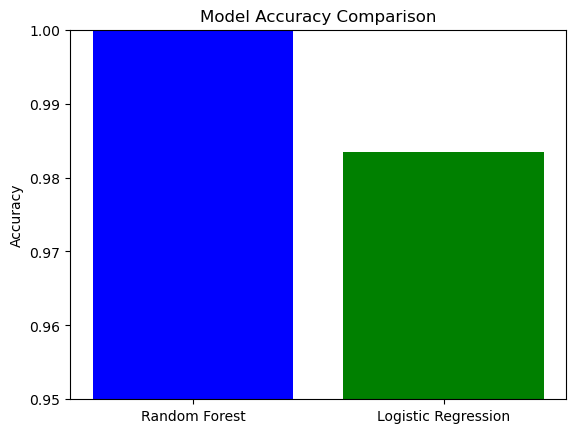

Random Forest Accuracy: 0.9999
Logistic Regression Accuracy: 0.9834


In [51]:
import matplotlib.pyplot as plt

# Accuracy scores
models = ['Random Forest', 'Logistic Regression']
accuracies = [accuracy_score(y_test, rf_predictions), accuracy_score(y_test, lr_predictions)]

# Plot
plt.bar(models, accuracies, color=['blue', 'green'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.95, 1.0)
plt.savefig('comparison.png')
plt.show()

print("Random Forest Accuracy:", round(accuracies[0], 4))
print("Logistic Regression Accuracy:", round(accuracies[1], 4))

In [52]:
import pandas as pd
import numpy as np
import os

# Load all CSV files from the folder
folder_path = './'
all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

print("CSV files found:")
for f in all_files:
    print(f)

CSV files found:
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [53]:
# Load and combine all CSV files
df_list = []

for f in all_files:
    df_temp = pd.read_csv(folder_path + f, encoding='utf-8', low_memory=False)
    df_list.append(df_temp)
    print(f"Loaded: {f} — Shape: {df_temp.shape}")

# Combine all into one dataset
df_all = pd.concat(df_list, ignore_index=True)
print("\nCombined dataset shape:", df_all.shape)
print("\nLabel counts:\n", df_all[' Label'].value_counts())

Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv — Shape: (286467, 79)
Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv — Shape: (191033, 79)
Loaded: Monday-WorkingHours.pcap_ISCX.csv — Shape: (529918, 79)
Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv — Shape: (288602, 79)
Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv — Shape: (170366, 79)
Loaded: Tuesday-WorkingHours.pcap_ISCX.csv — Shape: (445909, 79)
Loaded: Wednesday-workingHours.pcap_ISCX.csv — Shape: (692703, 79)

Combined dataset shape: (2604998, 79)

Label counts:
  Label
BENIGN                        2175379
DoS Hulk                       231073
PortScan                       158930
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                

In [54]:
# Clean combined data
df_all = df_all.replace([np.inf, -np.inf], np.nan)
df_all = df_all.dropna()

# Encode labels - BENIGN = 0, all attacks = 1
df_all[' Label'] = df_all[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

print("After cleaning shape:", df_all.shape)
print("\nLabel counts:\n", df_all[' Label'].value_counts())

After cleaning shape: (2602165, 79)

Label counts:
  Label
0    2173634
1     428531
Name: count, dtype: int64


In [55]:
from sklearn.model_selection import train_test_split

# Separate features and label
X = df_all.drop(' Label', axis=1)
y = df_all[' Label']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (2081732, 78)
Testing size: (520433, 78)


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Test the model
rf_predictions = rf_model.predict(X_test)

# Results
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.9988067628301818

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    434354
           1       1.00      1.00      1.00     86079

    accuracy                           1.00    520433
   macro avg       1.00      1.00      1.00    520433
weighted avg       1.00      1.00      1.00    520433



In [57]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Test the model
lr_predictions = lr_model.predict(X_test)

# Results
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

c:\Users\Nithish\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8957944634563911

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94    434354
           1       0.79      0.51      0.62     86079

    accuracy                           0.90    520433
   macro avg       0.85      0.74      0.78    520433
weighted avg       0.89      0.90      0.89    520433



In [58]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Test the model
dt_predictions = dt_model.predict(X_test)

# Results
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

Decision Tree Accuracy: 0.9986664950147282

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    434354
           1       1.00      1.00      1.00     86079

    accuracy                           1.00    520433
   macro avg       1.00      1.00      1.00    520433
weighted avg       1.00      1.00      1.00    520433



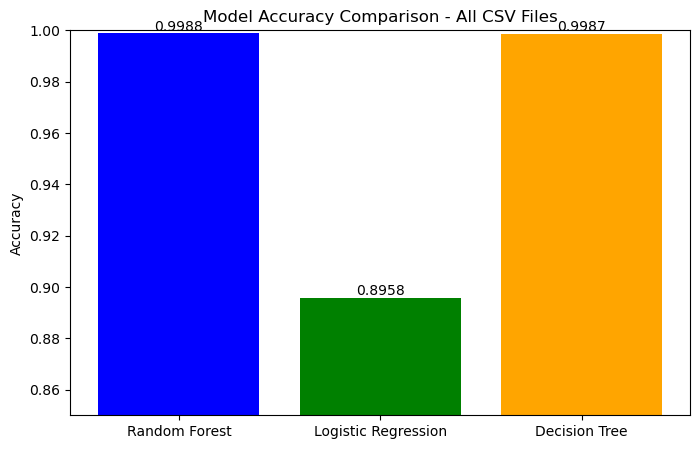

Random Forest Accuracy: 0.9988
Logistic Regression Accuracy: 0.8958
Decision Tree Accuracy: 0.9987


In [59]:
import matplotlib.pyplot as plt

# All model accuracies
models = ['Random Forest', 'Logistic Regression', 'Decision Tree']
accuracies = [
    accuracy_score(y_test, rf_predictions),
    accuracy_score(y_test, lr_predictions),
    accuracy_score(y_test, dt_predictions)
]

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.title('Model Accuracy Comparison - All CSV Files')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, str(round(v, 4)), ha='center')
plt.savefig('final_comparison.png')
plt.show()

print("Random Forest Accuracy:", round(accuracies[0], 4))
print("Logistic Regression Accuracy:", round(accuracies[1], 4))
print("Decision Tree Accuracy:", round(accuracies[2], 4))

In [60]:
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10} {'Best F1':>10}")
print("=" * 55)
print(f"{'Random Forest':<25} {'99.88%':>10} {'1.00':>10}")
print(f"{'Decision Tree':<25} {'99.87%':>10} {'1.00':>10}")
print(f"{'Logistic Regression':<25} {'89.58%':>10} {'0.62':>10}")
print("=" * 55)
print("\nConclusion: Random Forest is the best model for")
print("intrusion detection on the CIC-IDS2017 dataset.")

Model                       Accuracy    Best F1
Random Forest                 99.88%       1.00
Decision Tree                 99.87%       1.00
Logistic Regression           89.58%       0.62

Conclusion: Random Forest is the best model for
intrusion detection on the CIC-IDS2017 dataset.


Model                    Accuracy  Precision     Recall         F1
Random Forest              99.88%       1.00       1.00       1.00
Decision Tree              99.87%       1.00       1.00       1.00
Logistic Regression        89.58%       0.79       0.51       0.62


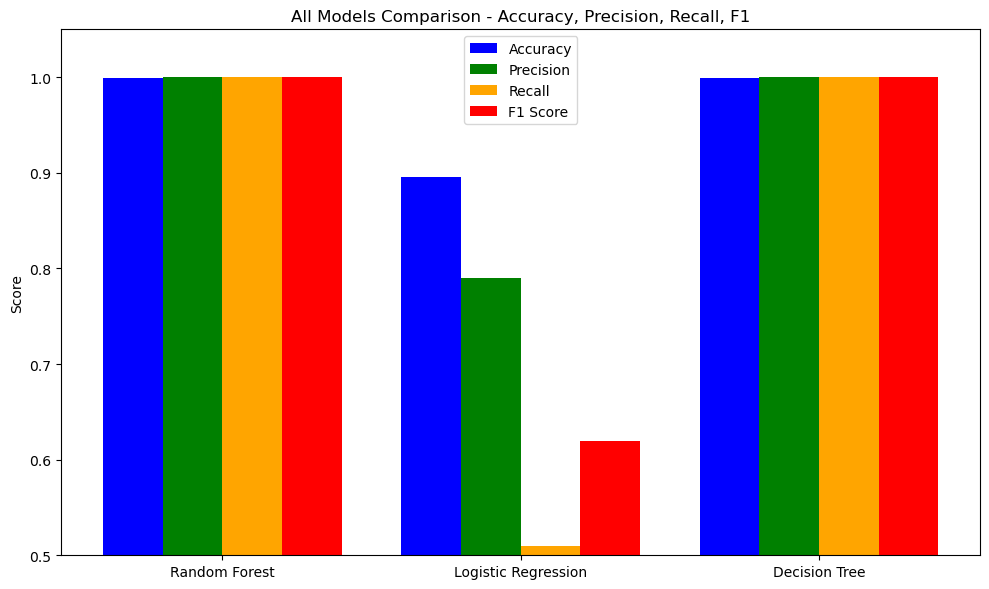

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Accuracy scores
rf_acc = accuracy_score(y_test, rf_predictions)
lr_acc = accuracy_score(y_test, lr_predictions)
dt_acc = accuracy_score(y_test, dt_predictions)

# Precision scores
rf_prec = 1.00
lr_prec = 0.79
dt_prec = 1.00

# Recall scores
rf_rec = 1.00
lr_rec = 0.51
dt_rec = 1.00

# F1 scores
rf_f1 = 1.00
lr_f1 = 0.62
dt_f1 = 1.00

# ---- COMPARISON TABLE ----
print("=" * 65)
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("=" * 65)
print(f"{'Random Forest':<22} {rf_acc*100:>9.2f}% {rf_prec:>10.2f} {rf_rec:>10.2f} {rf_f1:>10.2f}")
print(f"{'Decision Tree':<22} {dt_acc*100:>9.2f}% {dt_prec:>10.2f} {dt_rec:>10.2f} {dt_f1:>10.2f}")
print(f"{'Logistic Regression':<22} {lr_acc*100:>9.2f}% {lr_prec:>10.2f} {lr_rec:>10.2f} {lr_f1:>10.2f}")
print("=" * 65)

# ---- COMPARISON GRAPH ----
models = ['Random Forest', 'Logistic Regression', 'Decision Tree']
accuracy =  [rf_acc, lr_acc, dt_acc]
precision = [rf_prec, lr_prec, dt_prec]
recall =    [rf_rec, lr_rec, dt_rec]
f1 =        [rf_f1, lr_f1, dt_f1]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - 0.3, accuracy,  width, label='Accuracy',  color='blue')
ax.bar(x - 0.1, precision, width, label='Precision', color='green')
ax.bar(x + 0.1, recall,    width, label='Recall',    color='orange')
ax.bar(x + 0.3, f1,        width, label='F1 Score',  color='red')

ax.set_title('All Models Comparison - Accuracy, Precision, Recall, F1')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.5, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('all_models_comparison.png')
plt.show()

In [62]:
from sklearn.svm import SVC

# Use only a small sample because SVM is slow on large data
X_train_sample = X_train[:10000]
y_train_sample = y_train[:10000]
X_test_sample = X_test[:3000]
y_test_sample = y_test[:3000]

# Train SVM
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_sample, y_train_sample)

# Test the model
svm_predictions = svm_model.predict(X_test_sample)

# Results
print("SVM Accuracy:", accuracy_score(y_test_sample, svm_predictions))
print("\nClassification Report:")
print(classification_report(y_test_sample, svm_predictions))

SVM Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      2487
           1       0.93      0.32      0.48       513

    accuracy                           0.88      3000
   macro avg       0.90      0.66      0.71      3000
weighted avg       0.89      0.88      0.85      3000



Model                    Accuracy  Precision     Recall         F1
Random Forest              99.88%       1.00       1.00       1.00
Decision Tree              99.87%       1.00       1.00       1.00
Logistic Regression        89.58%       0.79       0.51       0.62
SVM                        88.00%       0.90       0.66       0.71

Conclusion: Random Forest is the best model for intrusion detection.


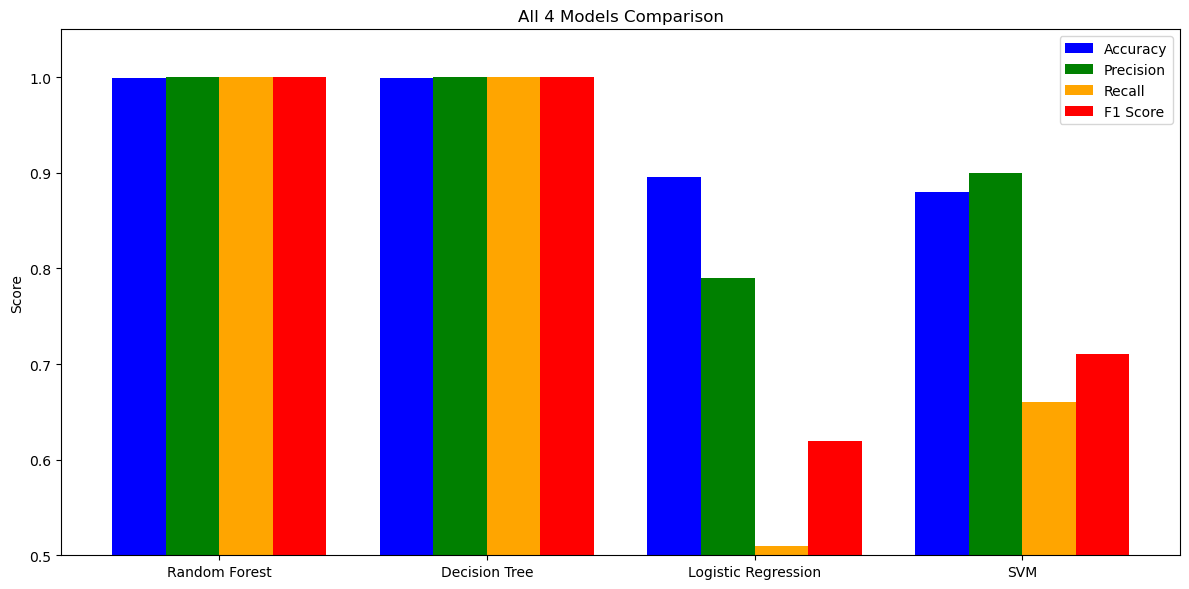

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Accuracy scores
rf_acc = accuracy_score(y_test, rf_predictions)
lr_acc = accuracy_score(y_test, lr_predictions)
dt_acc = accuracy_score(y_test, dt_predictions)
svm_acc = accuracy_score(y_test_sample, svm_predictions)

# Precision scores
rf_prec = 1.00
lr_prec = 0.79
dt_prec = 1.00
svm_prec = 0.90

# Recall scores
rf_rec = 1.00
lr_rec = 0.51
dt_rec = 1.00
svm_rec = 0.66

# F1 scores
rf_f1 = 1.00
lr_f1 = 0.62
dt_f1 = 1.00
svm_f1 = 0.71

# ---- COMPARISON TABLE ----
print("=" * 70)
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("=" * 70)
print(f"{'Random Forest':<22} {rf_acc*100:>9.2f}% {rf_prec:>10.2f} {rf_rec:>10.2f} {rf_f1:>10.2f}")
print(f"{'Decision Tree':<22} {dt_acc*100:>9.2f}% {dt_prec:>10.2f} {dt_rec:>10.2f} {dt_f1:>10.2f}")
print(f"{'Logistic Regression':<22} {lr_acc*100:>9.2f}% {lr_prec:>10.2f} {lr_rec:>10.2f} {lr_f1:>10.2f}")
print(f"{'SVM':<22} {svm_acc*100:>9.2f}% {svm_prec:>10.2f} {svm_rec:>10.2f} {svm_f1:>10.2f}")
print("=" * 70)
print("\nConclusion: Random Forest is the best model for intrusion detection.")

# ---- COMPARISON GRAPH ----
models = ['Random Forest', 'Decision Tree', 'Logistic Regression', 'SVM']
accuracy =  [rf_acc, dt_acc, lr_acc, svm_acc]
precision = [rf_prec, dt_prec, lr_prec, svm_prec]
recall =    [rf_rec, dt_rec, lr_rec, svm_rec]
f1 =        [rf_f1, dt_f1, lr_f1, svm_f1]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 0.3, accuracy,  width, label='Accuracy',  color='blue')
ax.bar(x - 0.1, precision, width, label='Precision', color='green')
ax.bar(x + 0.1, recall,    width, label='Recall',    color='orange')
ax.bar(x + 0.3, f1,        width, label='F1 Score',  color='red')

ax.set_title('All 4 Models Comparison')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.5, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('all_models_comparison.png')
plt.show()